# VPN Traffic Obfuscation - Comprehensive Analysis
## 1. Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import json
import glob
import os
import numpy as np

# Configure Aesthetics
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['figure.figsize'] = [16, 9]
plt.rcParams['font.size'] = 22
plt.rcParams['axes.titlesize'] = 22
plt.rcParams['axes.labelsize'] = 22
plt.rcParams['xtick.labelsize'] = 22
plt.rcParams['ytick.labelsize'] = 22
plt.rcParams['legend.fontsize'] = 22

RESULTS_DIR = "../results/runs"

def load_runs(base_dir):
    runs_data = []
    
    # Structure: results/runs/<scenario>/<timestamp>/metadata.json
    meta_files = glob.glob(os.path.join(base_dir, "**", "metadata.json"), recursive=True)
    
    # Filter out metadata.json inside subdirectories (e.g. suricata/metadata.json)
    # and exclude validation runs — only keep top-level run metadata
    filtered = []
    for mf in meta_files:
        parent = os.path.basename(os.path.dirname(mf))
        # Skip if parent is a known subdirectory (suricata, zeek, pcap, etc.)
        if parent in ('suricata', 'zeek', 'pcap', 'pcap_features', 'iperf'):
            continue
        # Skip validation runs
        run_path = os.path.dirname(mf)
        if '/validation/' in run_path:
            continue
        filtered.append(mf)
    
    meta_files = filtered
    print(f"Found {len(meta_files)} scenario runs.")
    
    for meta_path in meta_files:
        run_path = os.path.dirname(meta_path)
        
        # 1. Load Metadata
        try:
            with open(meta_path, 'r') as f:
                meta = json.load(f)
        except Exception as e:
            print(f"Skipping {run_path}: Invalid metadata ({e})")
            continue
        
        # Skip runs without a valid scenario
        scenario = meta.get("scenario", "unknown")
        if scenario in ("unknown", "validation"):
            continue
            
        run_data = {
            "id": os.path.basename(run_path),
            "path": run_path,
            "scenario": scenario,
            "mode": meta.get("mode", "unknown"),
            "seed": meta.get("seed", "N/A"),
            "timestamp": meta.get("timestamp", "N/A"),
            "suricata_version": meta.get("versions", {}).get("suricata", "N/A"),
            "zeek_version": meta.get("versions", {}).get("zeek", "N/A"),
            "tshark_version": meta.get("versions", {}).get("tshark", "N/A"),
            "suricata_rules_count": meta.get("loaded_rules_count", 0)
        }
        
        # Load Suricata rules count from suricata subdirectory metadata if available
        suri_meta_path = os.path.join(run_path, "suricata", "metadata.json")
        if os.path.exists(suri_meta_path) and run_data["suricata_rules_count"] == 0:
            try:
                with open(suri_meta_path) as f:
                    suri_meta = json.load(f)
                    run_data["suricata_rules_count"] = suri_meta.get("loaded_rules_count", 0)
            except: pass
        
        # 2. Load Suricata Alerts (EVE JSON)
        eve_path = os.path.join(run_path, "suricata", "eve.json")
        alerts = []
        if os.path.exists(eve_path):
            try:
                with open(eve_path, 'r') as f:
                    for line in f:
                        entry = json.loads(line)
                        if entry.get('event_type') == 'alert':
                            alerts.append(entry.get('alert'))
            except Exception as e: 
                print(f"Error reading eve.json in {run_path}: {e}")
        run_data["alerts"] = pd.DataFrame(alerts)
        
        # 3. Load Zeek Flows (Conn.log JSON)
        conn_path = os.path.join(run_path, "zeek", "conn.log")
        zeek_flows = []
        if os.path.exists(conn_path):
            try:
                with open(conn_path, 'r') as f:
                    first_char = f.read(1)
                
                if first_char == '{':
                    with open(conn_path, 'r') as f:
                        for line in f:
                            try:
                                zeek_flows.append(json.loads(line))
                            except: pass
                    run_data["zeek_df"] = pd.DataFrame(zeek_flows)
                else:
                    run_data["zeek_df"] = pd.read_csv(conn_path, sep="\t", comment="#", on_bad_lines='skip')
            except Exception as e:
                print(f"Error reading zeek conn.log in {run_path}: {e}")
                run_data["zeek_df"] = pd.DataFrame()
        else:
            run_data["zeek_df"] = pd.DataFrame()
            
        # 4. Load Packet Features (CSV)
        packet_path = os.path.join(run_path, "pcap_features", "packets.csv")
        if os.path.exists(packet_path):
            try:
                run_data["packets_df"] = pd.read_csv(packet_path)
                run_data["packets_df"]['frame.len'] = pd.to_numeric(run_data["packets_df"]['frame.len'], errors='coerce')
                run_data["packets_df"]['frame.time_epoch'] = pd.to_numeric(run_data["packets_df"]['frame.time_epoch'], errors='coerce')
            except Exception as e:
                print(f"Error reading packets.csv in {run_path}: {e}")
                run_data["packets_df"] = pd.DataFrame()
        else:
            run_data["packets_df"] = pd.DataFrame()

        # 5. Load Performance (iPerf JSON)
        iperf_path = os.path.join(run_path, "iperf", "iperf.json")
        run_data["throughput_mbps"] = 0.0
        run_data["retransmits"] = 0
        
        if os.path.exists(iperf_path):
            try:
                with open(iperf_path, 'r') as f:
                    iperf_data = json.load(f)
                    end = iperf_data.get('end', {})
                    sum_received = end.get('sum_received', {})
                    sum_sent    = end.get('sum_sent', {})
                    bps = sum_received.get('bits_per_second', 0)
                    run_data["throughput_mbps"] = bps / 1e6
                    run_data["retransmits"] = sum_sent.get('retransmits', 0)
            except:
                pass

        runs_data.append(run_data)
        
    return pd.DataFrame(runs_data)

df_runs = load_runs(RESULTS_DIR)

# Enrich Label
if not df_runs.empty:
    df_runs['label'] = df_runs['scenario'] + " (" + df_runs['mode'] + ")"
    
    if 'packets_df' not in df_runs.columns:
        df_runs['packets_df'] = None
    if 'zeek_df' not in df_runs.columns:
        df_runs['zeek_df'] = None

    print(f"Successfully loaded {len(df_runs)} runs.")
    display(df_runs[['id', 'scenario', 'mode', 'timestamp', 'seed', 'suricata_rules_count']].sort_values('timestamp', ascending=False))
else:
    print("No valid runs found. Please execute experiment scripts first.")

Found 9 scenario runs.
Successfully loaded 9 runs.


,id,scenario,mode,timestamp,seed,suricata_rules_count
4,20-04-2026-13-24-10,baseline,streaming,2026-04-20T13:27:09Z,1776691520,49705
3,20-04-2026-13-21-26,baseline,streaming,2026-04-20T13:24:02Z,1776691333,49705
8,20-04-2026-13-05-37,obfs4,streaming,2026-04-20T13:08:38Z,1776690408,49705
6,20-04-2026-12-59-54,obfs4,streaming,2026-04-20T13:02:57Z,1776690065,49705
7,20-04-2026-12-57-24,obfs4,burst,2026-04-20T12:59:27Z,1776689915,49705
2,20-04-2026-12-54-03,udp2raw,streaming,2026-04-20T12:56:59Z,1776689714,49705
1,20-04-2026-12-50-10,udp2raw,streaming,2026-04-20T12:53:05Z,1776689481,49705
0,20-04-2026-12-47-16,udp2raw,burst,2026-04-20T12:49:25Z,1776689307,49705
5,20-04-2026-12-30-26,baseline,burst,2026-04-20T12:32:20Z,1776688282,49705


## 2. IDS-Sichtbarkeit (Suricata, Zeek & nDPI)
Wie gut erkennen die Sicherheitswerkzeuge den VPN-Traffic?

Suricata läuft mit **zwei parallelen Regelwerken**:
1. *ET Open* — Community-Signaturen (z. B. `ET POLICY WireGuard VPN Handshake`).
2. *Custom Behavioral Rules* (SID 9000001–9000002) — eigens für diese Arbeit geschrieben. Sie matchen WireGuard-Handshake-Pakete anhand der **Payload-Struktur**, nicht des Ports:
   - **SID 9000001** `CUSTOM WireGuard Handshake Initiator` — UDP-Payload exakt 148 B, erste 4 Bytes `01 00 00 00`.
   - **SID 9000002** `CUSTOM WireGuard Handshake Response` — UDP-Payload exakt 92 B, erste 4 Bytes `02 00 00 00`.

Sind die Obfuskierungsmaßnahmen wirksam, dürfen diese Regeln bei UDP2RAW und OBFS4 **nicht** auslösen.

### 2a. Suricata IDS Alerts

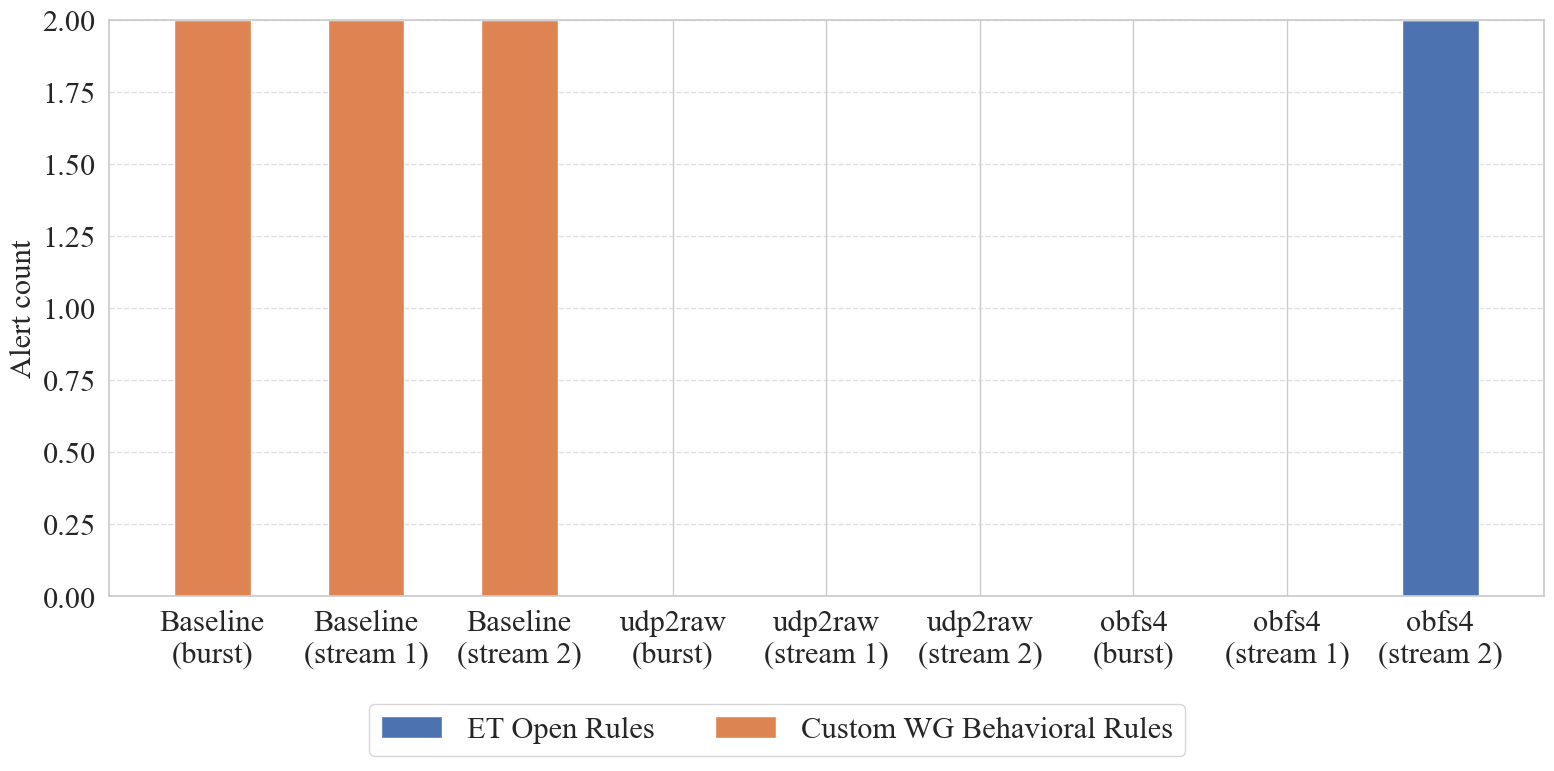


CUSTOM WIREGUARD BEHAVIORAL RULE HITS PER RUN
SID 9000001: Handshake Initiator (148 B, type=0x01)
SID 9000002: Handshake Response  ( 92 B, type=0x02)
  baseline (burst)                SID 9000001:   1   SID 9000002:   1   -> YES
  baseline (streaming)            SID 9000001:   1   SID 9000002:   1   -> YES
  baseline (streaming)            SID 9000001:   1   SID 9000002:   1   -> YES
  udp2raw (burst)                 SID 9000001:   0   SID 9000002:   0   -> no
  udp2raw (streaming)             SID 9000001:   0   SID 9000002:   0   -> no
  udp2raw (streaming)             SID 9000001:   0   SID 9000002:   0   -> no
  obfs4 (burst)                   SID 9000001:   0   SID 9000002:   0   -> no
  obfs4 (streaming)               SID 9000001:   0   SID 9000002:   0   -> no
  obfs4 (streaming)               SID 9000001:   0   SID 9000002:   0   -> no
Expected: baseline fires, udp2raw and obfs4 do NOT fire.


In [2]:
# SIDs of the custom behavioral WireGuard rules
WG_CUSTOM_SIDS = {9000001, 9000002}

if not df_runs.empty:
    from collections import defaultdict

    # Sort: baseline → udp2raw → obfs4, within each: burst first, then stream
    SCENARIO_ORDER = ['baseline', 'udp2raw', 'obfs4']
    MODE_ORDER = {'burst': 0, 'streaming': 1}
    df_runs['_s'] = df_runs['scenario'].map({s: i for i, s in enumerate(SCENARIO_ORDER)})
    df_runs['_m'] = df_runs['mode'].map(MODE_ORDER)
    df_runs = df_runs.sort_values(['_s', '_m', 'timestamp']).reset_index(drop=True)
    df_runs = df_runs.drop(columns=['_s', '_m'])

    DISPLAY = {'baseline': 'Baseline', 'udp2raw': 'udp2raw', 'obfs4': 'obfs4'}
    MODE_SHORT = {'streaming': 'stream', 'burst': 'burst'}

    counts = defaultdict(int)
    for _, row in df_runs.iterrows():
        counts[(row['scenario'], row['mode'])] += 1

    counters = defaultdict(int)
    unique_labels = []
    for _, row in df_runs.iterrows():
        key = (row['scenario'], row['mode'])
        counters[key] += 1
        name = DISPLAY.get(row['scenario'], row['scenario'])
        mode = MODE_SHORT.get(row['mode'], row['mode'])
        lbl = f"{name}\n({mode} {counters[key]})" if counts[key] > 1 else f"{name}\n({mode})"
        unique_labels.append(lbl)

    df_runs['unique_label'] = unique_labels

    # ── Per-run alert aggregation (all 9 runs) ────────────────────────────────
    alert_stats = []
    for i, (_, row) in enumerate(df_runs.iterrows()):
        alerts_df = row['alerts']
        count = len(alerts_df) if not alerts_df.empty else 0

        wg_custom_count = 0
        et_open_count   = 0
        if not alerts_df.empty and 'signature_id' in alerts_df.columns:
            try:
                sids = pd.to_numeric(alerts_df['signature_id'], errors='coerce')
                wg_custom_count = int(sids.isin(WG_CUSTOM_SIDS).sum())
                et_open_count   = count - wg_custom_count
            except:
                et_open_count = count
        else:
            et_open_count = count

        alert_stats.append({
            'unique_label': unique_labels[i],
            'scenario':     row['scenario'],
            'mode':         row['mode'],
            'total_alerts': count,
            'wg_custom':    wg_custom_count,
            'et_open':      et_open_count,
        })

    df_alerts = pd.DataFrame(alert_stats)

    # ── Figure: stacked bar (all 9 runs) ─────────────────────────────────────
    fig, ax = plt.subplots(figsize=(16,8))
    x = range(len(df_alerts))
    ax.bar(x, df_alerts['et_open'], label='ET Open Rules', color='#4c72b0', width=0.5)
    ax.bar(x, df_alerts['wg_custom'], label='Custom WG Behavioral Rules', bottom=df_alerts['et_open'], color='#dd8452', width=0.5)
    ax.set_xticks(list(x))
    ax.set_xticklabels(df_alerts['unique_label'], rotation=0, ha='center', fontsize=22)
    ax.set_ylabel("Alert count", fontsize=22)
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=22, frameon=True)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.225)
    plt.show()

    # ── Custom rule hit table ─────────────────────────────────────────────────
    print("\n" + "=" * 70)
    print("CUSTOM WIREGUARD BEHAVIORAL RULE HITS PER RUN")
    print("SID 9000001: Handshake Initiator (148 B, type=0x01)")
    print("SID 9000002: Handshake Response  ( 92 B, type=0x02)")
    print("=" * 70)
    for _, row in df_runs.iterrows():
        alerts_df = row['alerts']
        if alerts_df.empty or 'signature_id' not in alerts_df.columns:
            hit_9000001, hit_9000002 = 0, 0
        else:
            sids = pd.to_numeric(alerts_df['signature_id'], errors='coerce')
            hit_9000001 = int((sids == 9000001).sum())
            hit_9000002 = int((sids == 9000002).sum())
        fired = "YES" if (hit_9000001 + hit_9000002) > 0 else "no"
        print(f"  {row['label']:<30}  SID 9000001: {hit_9000001:>3}   SID 9000002: {hit_9000002:>3}   -> {fired}")
    print("=" * 70)
    print("Expected: baseline fires, udp2raw and obfs4 do NOT fire.")


### 2b. Zeek Protokollerkennung

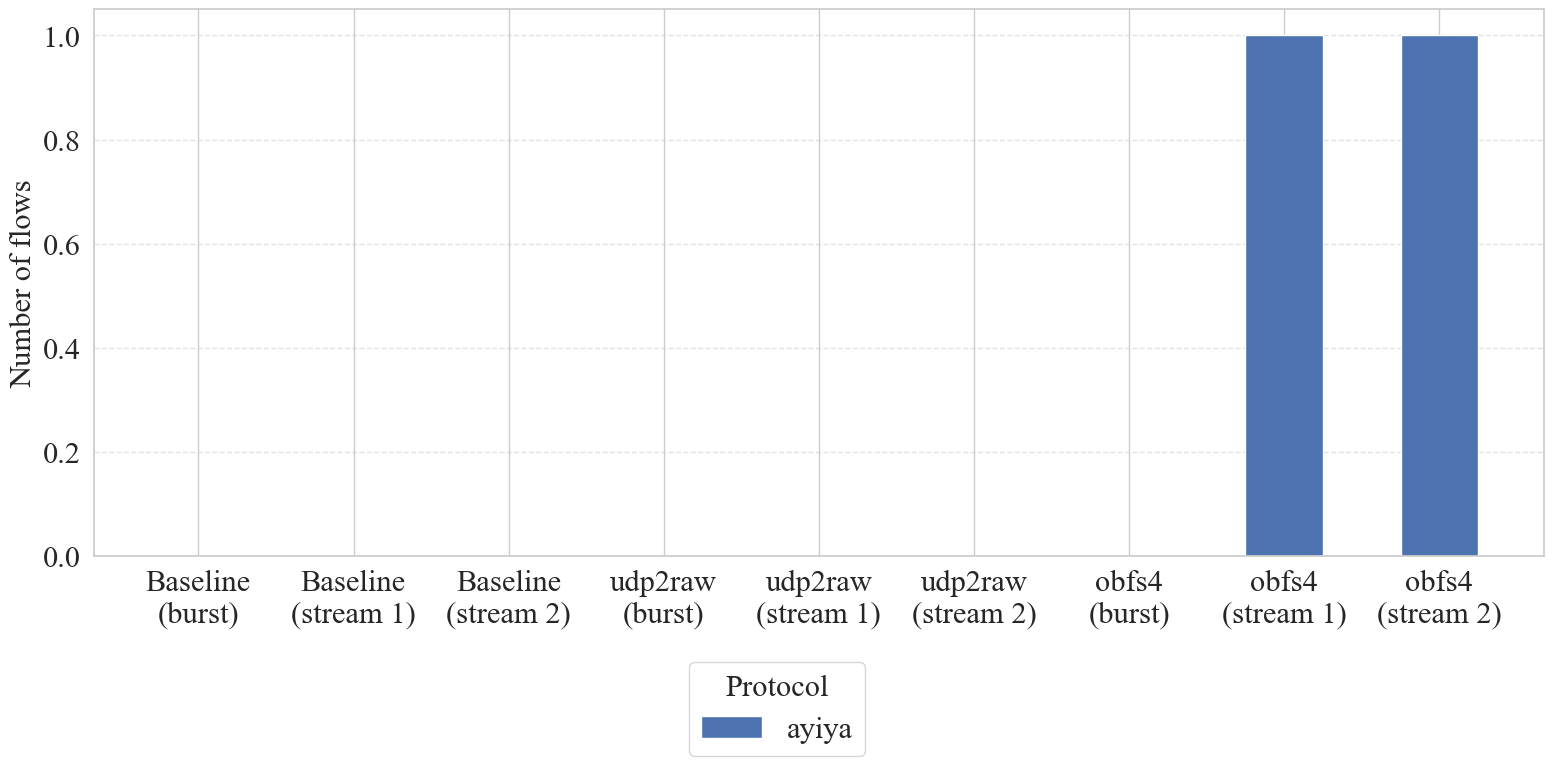

In [3]:
# ── Zeek protocol detection (all 9 runs) ────────────────────────────────────
if not df_runs.empty:
    all_run_labels = list(df_runs['unique_label'])

    zeek_proto_stats = []
    for _, row in df_runs.iterrows():
        zdf = row['zeek_df']
        if zdf is not None and not zdf.empty and 'service' in zdf.columns:
            services = zdf['service'].replace('-', 'unknown').fillna('unknown')
            counts_s = services.value_counts(normalize=True).reset_index()
            counts_s.columns = ['service', 'ratio']
            counts_s = counts_s[counts_s['service'] != 'unknown']
            if not counts_s.empty:
                counts_s['run_label'] = row['unique_label']
                zeek_proto_stats.append(counts_s)

    fig, ax = plt.subplots(figsize=(16, 8))
    x = np.arange(len(all_run_labels))
    label_to_idx = {lbl: i for i, lbl in enumerate(all_run_labels)}
    COLORS = ['#4c72b0', '#dd8452', '#55a868', '#c44e52', '#8172b2']

    if zeek_proto_stats:
        df_zeek = pd.concat(zeek_proto_stats)
        protocols = df_zeek['service'].unique()
        bottom = np.zeros(len(all_run_labels))
        for pi, proto in enumerate(protocols):
            heights = np.zeros(len(all_run_labels))
            for _, r in df_zeek[df_zeek['service'] == proto].iterrows():
                idx = label_to_idx.get(r['run_label'])
                if idx is not None:
                    heights[idx] = r['ratio']
            ax.bar(x, heights, bottom=bottom, width=0.5,
                   color=COLORS[pi % len(COLORS)], label=proto)
            bottom += heights
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=22,
               title='Protocol', title_fontsize=22, frameon=True)

    ax.set_xticks(x)
    ax.set_xticklabels(all_run_labels, rotation=0, ha='center', fontsize=22)
    ax.set_ylabel("Number of flows", fontsize=22)    
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.275)
    plt.show()


### 2c. Deep Packet Inspection (nDPI)
nDPI performs protocol fingerprinting by analysing packet headers and payload patterns — going beyond Suricata's signature matching.
Unlike Suricata (which looks for known attack signatures), nDPI tries to **identify what protocol the traffic actually is**.

Key question: Can nDPI correctly identify WireGuard, or does obfuscation successfully disguise it?

In [4]:
if not df_runs.empty:
    ndpi_results = []
    
    for _, row in df_runs.iterrows():
        run_path = row['path']
        summary_path = os.path.join(run_path, "ndpi", "summary.txt")
        flows_path = os.path.join(run_path, "ndpi", "flows.csv")
        
        ndpi_proto = "N/A"
        ndpi_confidence = "N/A"
        ndpi_category = "N/A"
        total_packets = 0
        total_bytes = 0
        guessed_flows = 0
        
        # Parse summary.txt
        if os.path.exists(summary_path):
            with open(summary_path) as f:
                content = f.read()
            
            # Extract detected protocol line (first line after "Detected protocols:")
            import re
            proto_match = re.search(r'Detected protocols:\n\t(\S+)\s+packets:\s+(\d+)\s+bytes:\s+(\d+)', content)
            if proto_match:
                ndpi_proto = proto_match.group(1)
                total_packets = int(proto_match.group(2))
                total_bytes = int(proto_match.group(3))
            
            # Extract confidence (supports multi-word values like "Match by port")
            conf_match = re.search(r'Confidence:\s+(.+?)\s+(\d+)\s+\(flows\)', content)
            if conf_match:
                ndpi_confidence = conf_match.group(1).strip()
            
            # Extract protocol category
            cat_match = re.search(r'Protocol statistics:\n\t(\S+)', content)
            if cat_match:
                ndpi_category = cat_match.group(1)

            # Extract guessed flow protos
            guess_match = re.search(r'Guessed flow protos:\s+(\d+)', content)
            guessed_flows = int(guess_match.group(1)) if guess_match else 0
        
        # Parse flows.csv for additional details (ndpiReader uses '|' as delimiter)
        # Header starts with '#flow_id' so we read without comment= and strip the '#'
        ndpi_server_name = "N/A"
        if os.path.exists(flows_path):
            try:
                fdf = pd.read_csv(flows_path, sep='|', header=0)
                # Strip leading '#' from first column name (ndpiReader quirk)
                if len(fdf.columns) > 0 and fdf.columns[0].startswith('#'):
                    fdf.rename(columns={fdf.columns[0]: fdf.columns[0].lstrip('#')}, inplace=True)
                if not fdf.empty and 'server_name_sni' in fdf.columns and not fdf['server_name_sni'].isna().all():
                    ndpi_server_name = fdf['server_name_sni'].dropna().iloc[0] if len(fdf['server_name_sni'].dropna()) > 0 else "N/A"
            except Exception:
                pass
        
        ndpi_results.append({
            'Scenario': row['label'],
            'nDPI Protocol': ndpi_proto,
            'Confidence': ndpi_confidence,
            'Guessed Flow Protocols': guessed_flows,
            'Category': ndpi_category,
            'Packets': f"{total_packets:,}",
            'Bytes': f"{total_bytes:,}",
            'WireGuard Detected?': 'Yes' if ndpi_proto == 'WireGuard' else 'No'
        })
    
    df_ndpi = pd.DataFrame(ndpi_results)
    
    # Display table
    print("=" * 90)
    print("nDPI DEEP PACKET INSPECTION RESULTS")
    print("=" * 90)
    print()
    
    display(df_ndpi.style.set_caption(
        "nDPI Protocol Identification per Scenario"
    ).set_properties(**{'text-align': 'center'}).map(
        lambda v: 'background-color: #ffcccc; font-weight: bold' if v == 'Yes' else 
                  ('background-color: #ccffcc; font-weight: bold' if v == 'No' else ''),
        subset=['WireGuard Detected?']
    ))
    
    # Interpretation
    print()
    print("Interpretation:")
    for _, row in df_ndpi.iterrows():
        proto = row['nDPI Protocol']
        if proto == 'WireGuard':
            print(f"  ! {row['Scenario']}: WireGuard IDENTIFIED — no obfuscation, protocol headers visible")
        elif proto == 'TLS':
            print(f"  ~ {row['Scenario']}: Classified as TLS — FakeTCP mimics port 443 but lacks real TLS handshake")
        elif proto == 'Unknown':
            print(f"  + {row['Scenario']}: UNKNOWN — obfuscation effective, nDPI cannot identify the protocol")


nDPI DEEP PACKET INSPECTION RESULTS



,Scenario,nDPI Protocol,Confidence,Guessed Flow Protocols,Category,Packets,Bytes,WireGuard Detected?
0,baseline (burst),WireGuard,DPI,0,Acceptable,"3,265","3,903,330",Yes
1,baseline (streaming),WireGuard,DPI,0,Acceptable,"3,738,785","4,930,408,786",Yes
2,baseline (streaming),WireGuard,DPI,0,Acceptable,"3,797,300","5,009,935,804",Yes
3,udp2raw (burst),TLS,Match by port,1,Safe,"3,191","3,270,464",No
4,udp2raw (streaming),TLS,Match by port,1,Safe,"2,076,177","2,332,447,272",No
5,udp2raw (streaming),TLS,Match by port,1,Safe,"2,085,409","2,336,770,464",No
6,obfs4 (burst),Unknown,Unknown,0,Unrated,"4,494","4,802,254",No
7,obfs4 (streaming),Unknown,Unknown,0,Unrated,"2,496,910","2,891,465,086",No
8,obfs4 (streaming),Unknown,Unknown,0,Unrated,"2,463,565","2,852,948,717",No



Interpretation:
  ! baseline (burst): WireGuard IDENTIFIED — no obfuscation, protocol headers visible
  ! baseline (streaming): WireGuard IDENTIFIED — no obfuscation, protocol headers visible
  ! baseline (streaming): WireGuard IDENTIFIED — no obfuscation, protocol headers visible
  ~ udp2raw (burst): Classified as TLS — FakeTCP mimics port 443 but lacks real TLS handshake
  ~ udp2raw (streaming): Classified as TLS — FakeTCP mimics port 443 but lacks real TLS handshake
  ~ udp2raw (streaming): Classified as TLS — FakeTCP mimics port 443 but lacks real TLS handshake
  + obfs4 (burst): UNKNOWN — obfuscation effective, nDPI cannot identify the protocol
  + obfs4 (streaming): UNKNOWN — obfuscation effective, nDPI cannot identify the protocol
  + obfs4 (streaming): UNKNOWN — obfuscation effective, nDPI cannot identify the protocol


## 3. Traffic Fingerprinting (Packet-Level)
Analysis of packet sizes and Inter-Arrival Times (IAT) to identify obfuscation patterns.
We separate TCP and UDP traffic.

### 3a. Packet Size Distribution

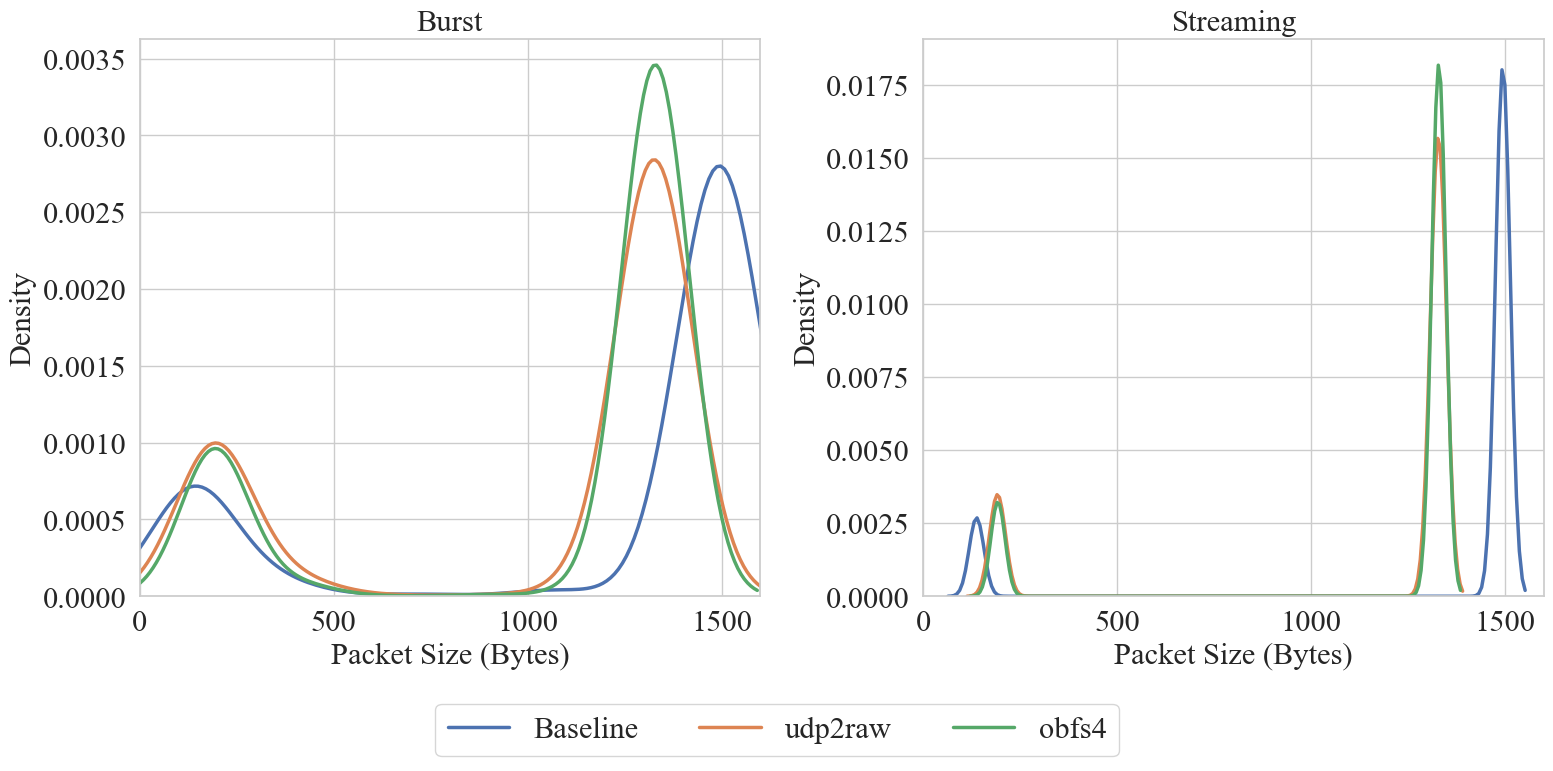

In [5]:
def calculate_iat(df):
    """Calculate Inter-Arrival Times in milliseconds."""
    if df is None or df.empty or 'frame.time_epoch' not in df.columns:
        return pd.Series(dtype=float)
    df_sorted = df.sort_values('frame.time_epoch')
    iat = df_sorted['frame.time_epoch'].diff().dropna()
    iat = iat[iat > 0] * 1000
    return iat.reset_index(drop=True)

if not df_runs.empty:
    valid_runs = df_runs[df_runs['packets_df'].apply(lambda x: x is not None and not x.empty)]

    if not valid_runs.empty:
        SCENARIO_ORDER  = ['baseline', 'udp2raw', 'obfs4']
        SCENARIO_LABELS = {'baseline': 'Baseline', 'udp2raw': 'udp2raw', 'obfs4': 'obfs4'}
        COLORS          = {'baseline': '#4c72b0', 'udp2raw': '#dd8452', 'obfs4': '#55a868'}

        burst_runs    = valid_runs[valid_runs['mode'] == 'burst']
        stream_runs   = valid_runs[valid_runs['mode'] == 'streaming']

        fig, axes = plt.subplots(1, 2, figsize=(16, 8))

        for ax, runs, title in [
            (axes[0], burst_runs,  'Burst'),
            (axes[1], stream_runs, 'Streaming'),
        ]:
            # One KDE per scenario — concatenate all packets of that scenario
            for scen in SCENARIO_ORDER:
                scen_runs = runs[runs['scenario'] == scen]
                if scen_runs.empty:
                    continue
                all_sizes = pd.concat([r['packets_df']['frame.len'].dropna()
                                       for _, r in scen_runs.iterrows()])
                sns.kdeplot(all_sizes, label=SCENARIO_LABELS[scen],
                            color=COLORS[scen], fill=False, linewidth=2.5, ax=ax)

            ax.set_xlabel("Packet Size (Bytes)", fontsize=22)
            ax.set_ylabel("Density", fontsize=22)
            ax.set_xlim(0, 1600)
            ax.tick_params(labelsize=22)
            ax.set_title(title, fontsize=22)

        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=22, frameon=True)
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.225)
        plt.show()


### 3b. Inter-Arrival Time (IAT) Distribution

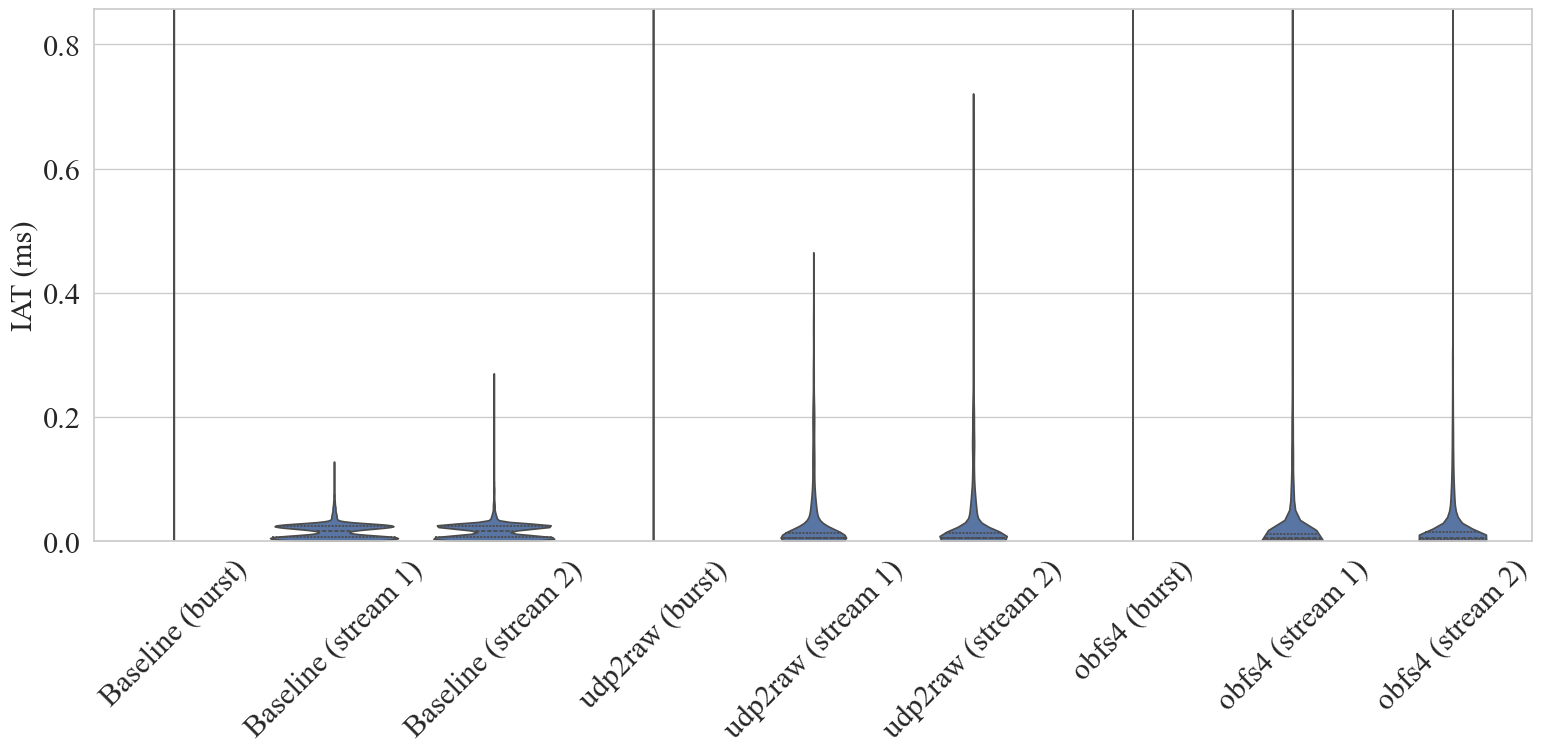

In [6]:
if not df_runs.empty:
    valid_runs = df_runs[df_runs['packets_df'].apply(lambda x: x is not None and not x.empty)]

    if not valid_runs.empty:
        iat_data = []
        for _, row in valid_runs.iterrows():
            pdf = row['packets_df']
            if pdf.empty: continue
            iat = calculate_iat(pdf)
            if len(iat) == 0: continue
            if len(iat) > 2000:
                iat = iat.sample(2000, random_state=42)
            temp_df = pd.DataFrame({'iat_ms': iat})
            temp_df['label'] = row['unique_label'].replace('\n', ' ')
            iat_data.append(temp_df)

        if iat_data:
            df_iat = pd.concat(iat_data)

            # Cap y-axis at 99th percentile to prevent outliers squishing violins
            y_cap = df_iat['iat_ms'].quantile(0.99)

            fig, ax = plt.subplots(figsize=(16, 8))
            sns.violinplot(data=df_iat, x='label', y='iat_ms', inner='quartile',
                           cut=0, ax=ax)
            ax.set_ylim(0, y_cap)
            ax.set_ylabel("IAT (ms)", fontsize=22)
            ax.set_xlabel("")
            ax.tick_params(axis='x', rotation=45, labelsize=22)
            ax.tick_params(axis='y', labelsize=22)
            plt.tight_layout()
            plt.show()


## 4. Protocol Plausibility Check
Does traffic on TCP/443 actually look like TLS? 
We check for `tls.handshake.type == 1` (Client Hello) in flows on port 443.

In [7]:
if not df_runs.empty:
    plausibility_stats = []
    
    for _, row in valid_runs.iterrows():
        pdf = row['packets_df']
        if pdf.empty: continue
        
        # Work on a copy
        pdf_tmp = pdf.copy()
        
        # Check for TCP destination port column
        has_tcp = 'tcp.dstport' in pdf_tmp.columns
        has_tls = 'tls.handshake.type' in pdf_tmp.columns
        
        if has_tcp:
            pdf_tmp['tcp.dstport'] = pd.to_numeric(pdf_tmp['tcp.dstport'], errors='coerce')
            total_443 = len(pdf_tmp[pdf_tmp['tcp.dstport'] == 443])
        else:
            total_443 = 0
        
        # Count TLS Client Hellos
        client_hellos = 0
        if has_tls and total_443 > 0:
            https_packets = pdf_tmp[pdf_tmp['tcp.dstport'] == 443]
            client_hellos = len(https_packets[https_packets['tls.handshake.type'] == 1])
        
        # Determine transport protocol from Zeek
        zdf = row['zeek_df']
        transport = "N/A"
        port = "N/A"
        if zdf is not None and not zdf.empty:
            transport = zdf['proto'].iloc[0] if 'proto' in zdf.columns else "N/A"
            port = str(zdf['id.resp_p'].iloc[0]) if 'id.resp_p' in zdf.columns else "N/A"
        
        plausibility_stats.append({
            'Scenario': row['label'],
            'Transport': f"{transport.upper()}/{port}",
            'Total Packets': len(pdf_tmp),
            'Packets on 443': total_443,
            'TLS Client Hellos': client_hellos,
            'TLS Hello Ratio': f"{client_hellos}/{total_443}" if total_443 > 0 else "N/A (no TCP/443)",
            'Plausible TLS?': "No" if total_443 > 0 and client_hellos == 0 else ("N/A" if total_443 == 0 else "Yes")
        })
    
    if plausibility_stats:
        df_plaus = pd.DataFrame(plausibility_stats)
        
        print("=" * 90)
        print("PROTOCOL PLAUSIBILITY CHECK — Does TCP/443 traffic contain real TLS?")
        print("=" * 90)
        print()
        display(df_plaus.style.set_caption(
            "Protocol Plausibility: TLS Client Hello detection on port 443"
        ).set_properties(**{'text-align': 'center'}).map(
            lambda v: 'background-color: #ffcccc' if v == 'No' else 
                      ('background-color: #ccffcc' if v == 'Yes' else ''),
            subset=['Plausible TLS?']
        ))
        
        print()
        print("Interpretation:")
        for _, row in df_plaus.iterrows():
            if row['Packets on 443'] > 0 and row['TLS Client Hellos'] == 0:
                print(f"  ! {row['Scenario']}: {row['Packets on 443']} packets on TCP/443 but "
                      f"0 TLS Client Hellos -> FakeTCP detected by DPI")
            elif row['Packets on 443'] == 0:
                print(f"  - {row['Scenario']}: No TCP/443 traffic (uses {row['Transport']})")
    else:
        print("No packet data available for plausibility analysis.")

PROTOCOL PLAUSIBILITY CHECK — Does TCP/443 traffic contain real TLS?



,Scenario,Transport,Total Packets,Packets on 443,TLS Client Hellos,TLS Hello Ratio,Plausible TLS?
0,baseline (burst),UDP/51820,3265,0,0,N/A (no TCP/443),N/A
1,baseline (streaming),UDP/51820,3738785,0,0,N/A (no TCP/443),N/A
2,baseline (streaming),UDP/51820,3797300,0,0,N/A (no TCP/443),N/A
3,udp2raw (burst),TCP/443,3091,856,0,0/856,No
4,udp2raw (streaming),TCP/443,2076079,1702154,0,0/1702154,No
5,udp2raw (streaming),TCP/443,2085310,1704397,0,0/1704397,No
6,obfs4 (burst),UDP/12345,4494,0,0,N/A (no TCP/443),N/A
7,obfs4 (streaming),UDP/12345,2496910,0,0,N/A (no TCP/443),N/A
8,obfs4 (streaming),UDP/12345,2463565,0,0,N/A (no TCP/443),N/A



Interpretation:
  - baseline (burst): No TCP/443 traffic (uses UDP/51820)
  - baseline (streaming): No TCP/443 traffic (uses UDP/51820)
  - baseline (streaming): No TCP/443 traffic (uses UDP/51820)
  ! udp2raw (burst): 856 packets on TCP/443 but 0 TLS Client Hellos -> FakeTCP detected by DPI
  ! udp2raw (streaming): 1702154 packets on TCP/443 but 0 TLS Client Hellos -> FakeTCP detected by DPI
  ! udp2raw (streaming): 1704397 packets on TCP/443 but 0 TLS Client Hellos -> FakeTCP detected by DPI
  - obfs4 (burst): No TCP/443 traffic (uses UDP/12345)
  - obfs4 (streaming): No TCP/443 traffic (uses UDP/12345)
  - obfs4 (streaming): No TCP/443 traffic (uses UDP/12345)


## 5. Performance Impact
Throughput comparison across scenarios with statistical aggregation.

Each scenario is run **twice in streaming mode** (60 s iperf3 each). Results are shown as
**mean ± 95 % confidence interval** to account for CPU-scheduling jitter, Docker-network variance,
and cache effects. Overhead is calculated relative to the baseline mean.

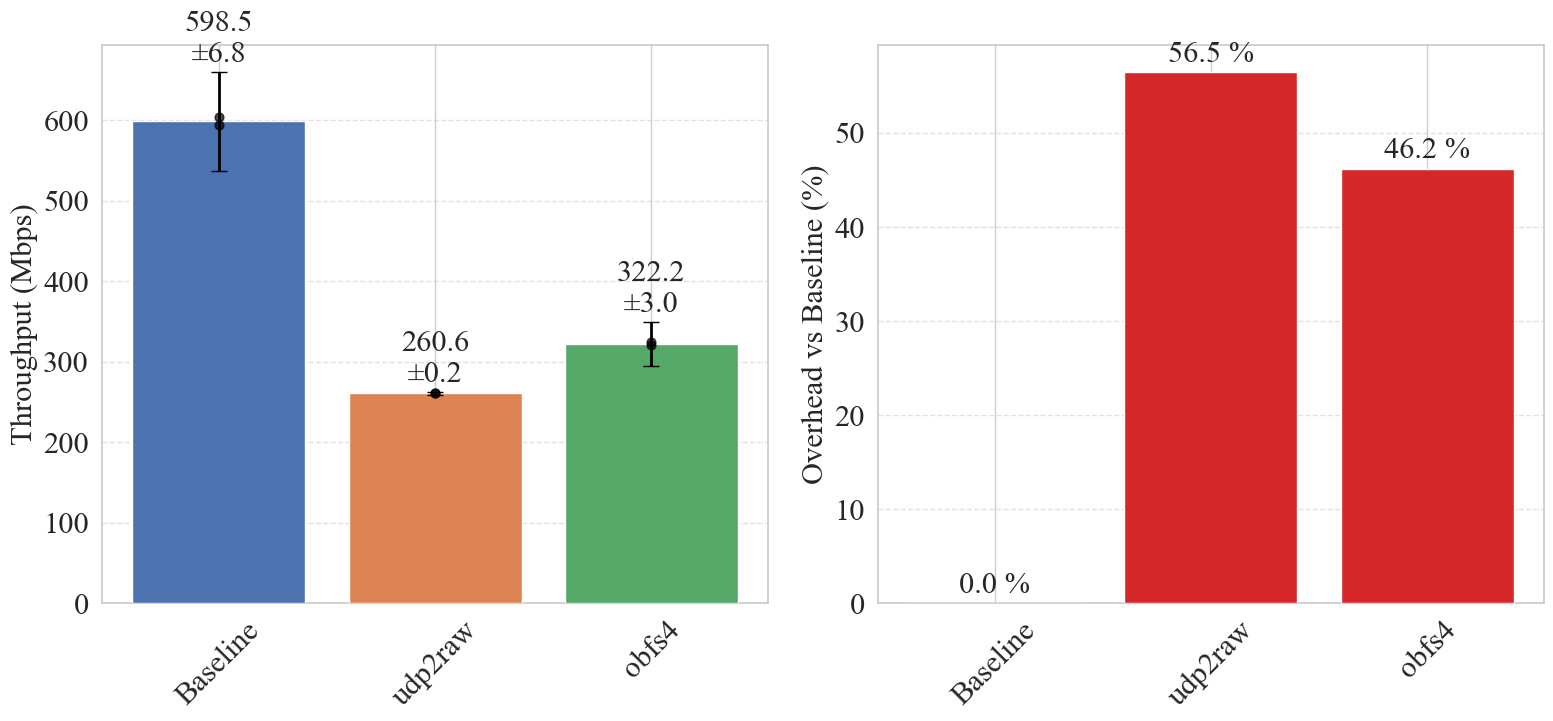


THROUGHPUT STATISTICS (Streaming mode, n runs per scenario)
Scenario       n   Mean (Mbps)  Std (Mbps)   95% CI (±)   Overhead
----------------------------------------------------------------------
baseline       2        598.51        6.81        61.18     +0.0 %
udp2raw        2        260.60        0.24         2.12    +56.5 %
obfs4          2        322.18        3.03        27.22    +46.2 %


In [8]:
if not df_runs.empty:
    # ── Only streaming runs carry valid iperf data ────────────────────
    stream_df = df_runs[(df_runs['mode'] == 'streaming') & (df_runs['throughput_mbps'] > 0)].copy()

    if stream_df.empty:
        print("No valid iPerf3 throughput data found (did you run 'streaming' mode?)")
    else:
        SCENARIO_ORDER = ['baseline', 'udp2raw', 'obfs4']
        SCENARIO_LABELS = {'baseline': 'Baseline',
                           'udp2raw':  'udp2raw',
                           'obfs4':    'obfs4'}

        # ── Aggregate: mean, std, n, 95 % CI per scenario ────────────
        agg = (stream_df.groupby('scenario')['throughput_mbps']
               .agg(['mean', 'std', 'count'])
               .rename(columns={'mean': 'mean_mbps', 'std': 'std_mbps', 'count': 'n'}))
        from scipy import stats as _st
        agg['ci95'] = agg.apply(
            lambda r: _st.t.ppf(0.975, df=max(r['n']-1, 1)) * r['std_mbps'] / np.sqrt(r['n'])
            if r['n'] > 1 else 0.0, axis=1)

        # Overhead vs baseline mean
        base_mean = agg.loc['baseline', 'mean_mbps'] if 'baseline' in agg.index else None
        if base_mean:
            agg['overhead_pct'] = ((base_mean - agg['mean_mbps']) / base_mean) * 100
        else:
            agg['overhead_pct'] = 0.0

        present = [s for s in SCENARIO_ORDER if s in agg.index]
        agg = agg.loc[present]

        x_labels = [SCENARIO_LABELS.get(s, s) for s in present]
        x_pos    = np.arange(len(present))

        fig, axes = plt.subplots(1, 2, figsize=(16, 8))

        # ── Left: Throughput with CI error bars ───────────────────────
        ax = axes[0]
        bars = ax.bar(x_pos, agg['mean_mbps'], yerr=agg['ci95'],
                      capsize=6, color=['#4c72b0', '#dd8452', '#55a868'],
                      error_kw={'elinewidth': 2, 'ecolor': 'black'}, zorder=3)

        # Scatter individual measurements on top
        for i, scen in enumerate(present):
            pts = stream_df[stream_df['scenario'] == scen]['throughput_mbps']
            ax.scatter([i] * len(pts), pts, color='black', zorder=4, s=40, alpha=0.7)

        ax.set_xticks(x_pos)
        ax.set_xticklabels(x_labels, ha='center', rotation=45)
        ax.set_ylabel("Throughput (Mbps)")

        ax.yaxis.grid(True, linestyle='--', alpha=0.6)

        # Annotate bars with mean ± std
        for bar, (_, row) in zip(bars, agg.iterrows()):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + row['ci95'] + 5,
                    f"{row['mean_mbps']:.1f}\n±{row['std_mbps']:.1f}",
                    ha='center', va='bottom', fontsize=22)

        # ── Right: Overhead % ─────────────────────────────────────────
        ax2 = axes[1]
        colors_oh = ['#4c72b0' if v <= 0 else '#d62728' for v in agg['overhead_pct']]
        ax2.bar(x_pos, agg['overhead_pct'], color=colors_oh, zorder=3)
        ax2.set_xticks(x_pos)
        ax2.set_xticklabels(x_labels, ha='center', rotation=45)
        ax2.set_ylabel("Overhead vs Baseline (%)")

        ax2.yaxis.grid(True, linestyle='--', alpha=0.6)
        for i, (_, row) in enumerate(agg.iterrows()):
            ax2.text(i, row['overhead_pct'] + 0.5, f"{row['overhead_pct']:.1f} %",
                     ha='center', va='bottom', fontsize=22)

        plt.tight_layout()
        plt.subplots_adjust(bottom=0.22)
        plt.show()

        # ── Statistics table ──────────────────────────────────────────
        print("\n" + "=" * 70)
        print("THROUGHPUT STATISTICS (Streaming mode, n runs per scenario)")
        print("=" * 70)
        print(f"{'Scenario':<12} {'n':>3}  {'Mean (Mbps)':>12}  {'Std (Mbps)':>10}  {'95% CI (±)':>11}  {'Overhead':>9}")
        print("-" * 70)
        for scen in present:
            r = agg.loc[scen]
            oh = f"{r['overhead_pct']:+.1f} %"
            print(f"{scen:<12} {int(r['n']):>3}  {r['mean_mbps']:>12.2f}  {r['std_mbps']:>10.2f}  {r['ci95']:>11.2f}  {oh:>9}")
        print("=" * 70)


## 6. Shannon Entropy Analysis
Entropy measures the randomness of packet payloads. Higher entropy indicates more effective obfuscation.
- **Baseline WireGuard**: Encrypted but with recognisable headers (Type 1-4, Reserved field) → slightly lower entropy.
- **UDP2RAW**: XOR-cipher wrapping → moderate entropy.
- **OBFS4**: Randomised padding + ChaCha20 encryption → expected near-maximum entropy.

We approximate payload entropy from packet sizes and byte distributions captured in the PCAP features.

In [9]:
import subprocess, tempfile, struct, math
from collections import Counter

def entropy_from_pcap(pcap_path, max_packets=2000):
    """Extract raw payload bytes from a PCAP and compute per-packet Shannon entropy.
    
    Tries multiple tshark fields because different protocols expose payload differently:
    - data.data: works for unknown/unrecognised protocols (e.g. OBFS4 on UDP)
    - udp.payload: works for UDP-based protocols (e.g. WireGuard)
    - tcp.payload: works for TCP-based protocols (e.g. UDP2RAW wrapping)
    """
    # Try payload fields in order of specificity
    payload_fields = ["data.data", "udp.payload", "tcp.payload"]
    
    best_entropies = []
    best_sizes = []
    
    for field in payload_fields:
        cmd = [
            "tshark", "-r", pcap_path, "-T", "fields",
            "-e", field,
            "-e", "frame.len",
            "-c", str(max_packets)
        ]
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=60)
        
        entropies = []
        sizes = []
        for line in result.stdout.strip().split("\n"):
            if not line.strip():
                continue
            parts = line.split("\t")
            hex_payload = parts[0] if len(parts) > 0 else ""
            frame_len = int(parts[1]) if len(parts) > 1 and parts[1] else 0
            
            if not hex_payload or len(hex_payload) < 4:
                continue
            
            try:
                raw = bytes.fromhex(hex_payload.replace(":", ""))
            except ValueError:
                continue
            
            if len(raw) == 0:
                continue
            
            counts = Counter(raw)
            length = len(raw)
            ent = -sum((c / length) * math.log2(c / length) for c in counts.values())
            entropies.append(ent)
            sizes.append(frame_len)
        
        # Keep the field that extracted the most payloads
        if len(entropies) > len(best_entropies):
            best_entropies = entropies
            best_sizes = sizes
    
    return best_entropies, best_sizes

# Compute entropy for all runs
if not df_runs.empty:
    entropy_data = []
    
    for _, row in df_runs.iterrows():
        run_path = row['path']
        pcap_dir = os.path.join(run_path, "pcap")
        
        if not os.path.isdir(pcap_dir):
            continue
        
        pcap_files = glob.glob(os.path.join(pcap_dir, "*.pcap"))
        if not pcap_files:
            continue
        
        pcap_path = pcap_files[0]
        print(f"Computing entropy for {row['label']} ({os.path.basename(pcap_path)})...")
        
        ents, szs = entropy_from_pcap(pcap_path, max_packets=3000)
        
        if ents:
            temp = pd.DataFrame({
                "entropy": ents,
                "frame_len": szs[:len(ents)],
                "label": row['label'],
                "scenario": row['scenario'],
                "mode": row['mode']
            })
            entropy_data.append(temp)
            print(f"  -> {len(ents)} packets, mean entropy: {np.mean(ents):.3f} bits")
        else:
            print(f"  -> No payload data extracted")
    
    if entropy_data:
        df_entropy = pd.concat(entropy_data, ignore_index=True)
        print(f"Loaded entropy for {df_entropy['scenario'].nunique()} scenarios, {len(df_entropy)} packets total.")
    else:
        print("No entropy data could be extracted. Check tshark availability.")

Computing entropy for baseline (burst) (wg-baseline.pcap)...
  -> 3000 packets, mean entropy: 7.507 bits
Computing entropy for baseline (streaming) (wg-baseline.pcap)...
  -> 3000 packets, mean entropy: 7.529 bits
Computing entropy for baseline (streaming) (wg-baseline.pcap)...
  -> 3000 packets, mean entropy: 7.561 bits
Computing entropy for udp2raw (burst) (wg-udp2raw.pcap)...
  -> 3000 packets, mean entropy: 7.365 bits
Computing entropy for udp2raw (streaming) (wg-udp2raw.pcap)...
  -> 3000 packets, mean entropy: 7.580 bits
Computing entropy for udp2raw (streaming) (wg-udp2raw.pcap)...
  -> 3000 packets, mean entropy: 7.579 bits
Computing entropy for obfs4 (burst) (wg-obfs4.pcap)...
  -> 3000 packets, mean entropy: 7.617 bits
Computing entropy for obfs4 (streaming) (wg-obfs4.pcap)...
  -> 3000 packets, mean entropy: 7.672 bits
Computing entropy for obfs4 (streaming) (wg-obfs4.pcap)...
  -> 3000 packets, mean entropy: 7.651 bits
Loaded entropy for 3 scenarios, 27000 packets total.


### 6a. Shannon Entropy Distribution

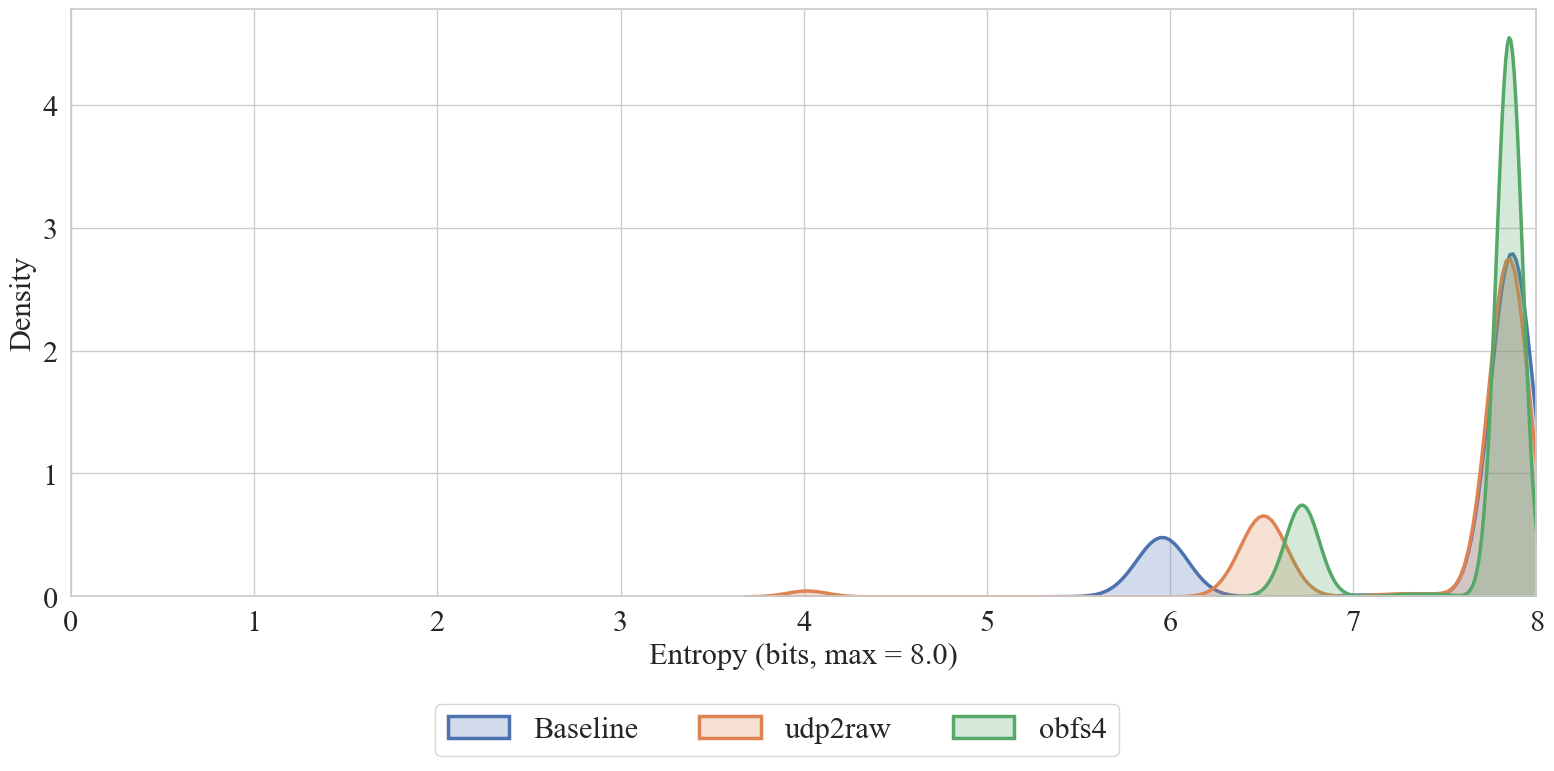

In [10]:
# ── 6a: Shannon Entropy Distribution (one KDE per scenario) ──────────────────
if 'df_entropy' in dir() and not df_entropy.empty:
    SCENARIO_ORDER  = ['baseline', 'udp2raw', 'obfs4']
    SCENARIO_LABELS = {'baseline': 'Baseline', 'udp2raw': 'udp2raw', 'obfs4': 'obfs4'}
    COLORS          = {'baseline': '#4c72b0', 'udp2raw': '#dd8452', 'obfs4': '#55a868'}

    fig, ax = plt.subplots(figsize=(16, 8))
    for scen in SCENARIO_ORDER:
        subset = df_entropy[df_entropy['scenario'] == scen]
        if subset.empty: continue
        sns.kdeplot(subset['entropy'], label=SCENARIO_LABELS[scen],
                    color=COLORS[scen], fill=True, alpha=0.25, linewidth=2.5, ax=ax)

    ax.set_xlabel("Entropy (bits, max = 8.0)", fontsize=22)
    ax.set_ylabel("Density", fontsize=22)
    ax.set_xlim(0, 8)
    ax.tick_params(labelsize=22)
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=22, frameon=True)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.225)
    plt.show()


### 6b. Entropy vs Packet Size

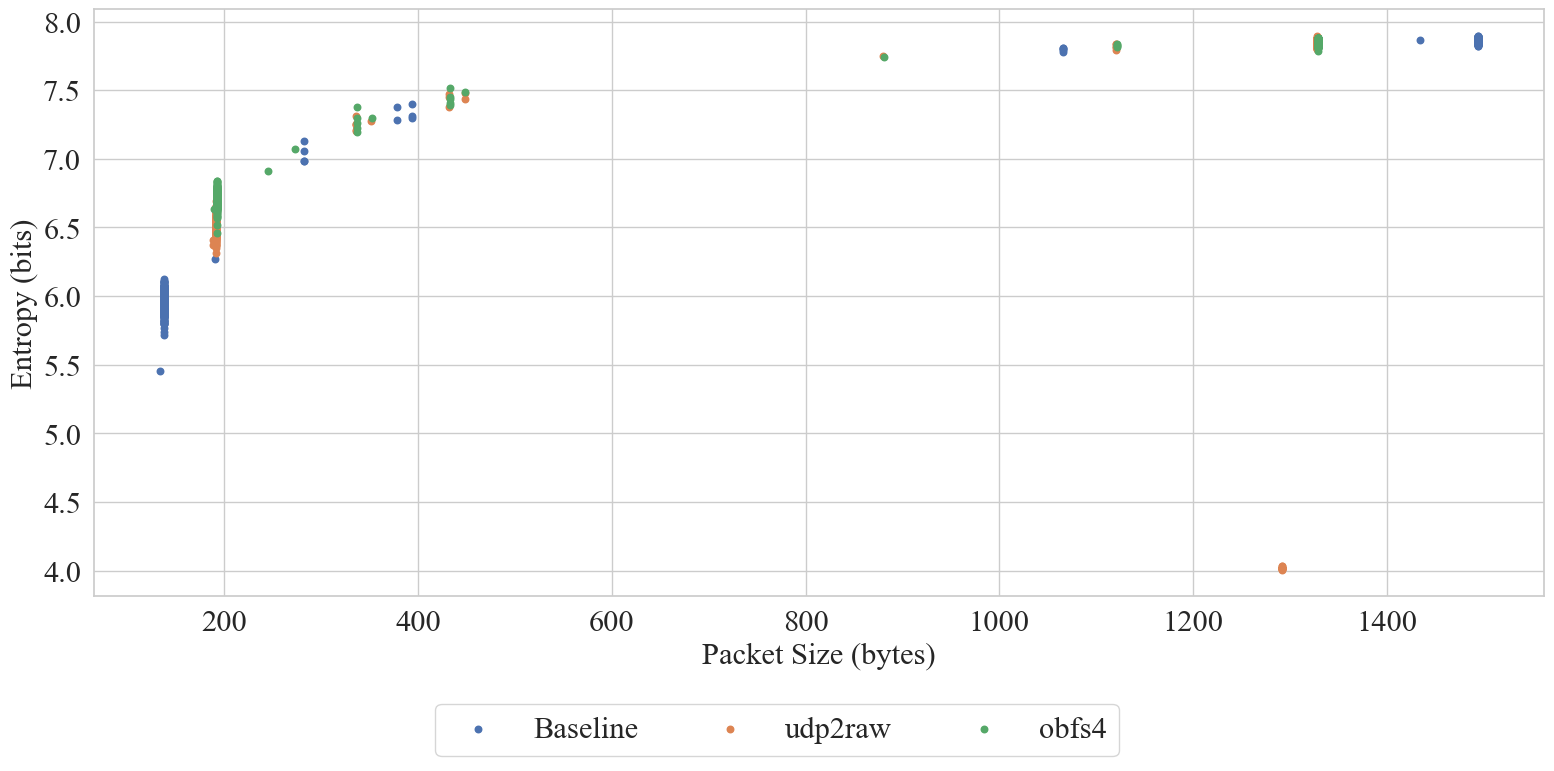

In [11]:
# ── 6b: Entropy vs Packet Size (one color per scenario) ──────────────────────
if 'df_entropy' in dir() and not df_entropy.empty:
    SCENARIO_ORDER  = ['baseline', 'udp2raw', 'obfs4']
    SCENARIO_LABELS = {'baseline': 'Baseline', 'udp2raw': 'udp2raw', 'obfs4': 'obfs4'}
    COLORS          = {'baseline': '#4c72b0', 'udp2raw': '#dd8452', 'obfs4': '#55a868'}

    fig, ax = plt.subplots(figsize=(16, 8))
    for scen in SCENARIO_ORDER:
        subset = df_entropy[df_entropy['scenario'] == scen]
        if subset.empty: continue
        if len(subset) > 1000:
            subset = subset.sample(1000, random_state=42)
        ax.scatter(subset['frame_len'], subset['entropy'],
                   label=SCENARIO_LABELS[scen], color=COLORS[scen],
                   alpha=1, s=22)

    ax.set_xlabel("Packet Size (bytes)", fontsize=22)
    ax.set_ylabel("Entropy (bits)", fontsize=22)
    ax.tick_params(labelsize=22)
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=22, frameon=True)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.225)
    plt.show()


## 7. Descriptive Statistics & Statistical Tests
Quantitative comparison of packet characteristics across all three scenarios.

- **Descriptive Statistics**: Mean, median, standard deviation, min/max for packet sizes and IAT.
- **Kolmogorov-Smirnov Test**: Pairwise comparison of packet size distributions to quantify how different the scenarios are from each other (p < 0.05 → significantly different distributions).
- **Entropy Statistics**: Per-scenario entropy summary.

In [12]:
from scipy import stats
from itertools import combinations

if not df_runs.empty:
    valid_runs = df_runs[df_runs['packets_df'].apply(lambda x: x is not None and not x.empty)]
    
    # ── 7a. Descriptive Statistics: Packet Size ──────────────────────
    print("=" * 80)
    print("7a. PACKET SIZE DESCRIPTIVE STATISTICS")
    print("=" * 80)
    
    pkt_stats = []
    for _, row in valid_runs.iterrows():
        pdf = row['packets_df']
        sizes = pdf['frame.len'].dropna()
        pkt_stats.append({
            'Scenario': row['label'],
            'Count': len(sizes),
            'Mean (B)': f"{sizes.mean():.1f}",
            'Median (B)': f"{sizes.median():.1f}",
            'Std Dev (B)': f"{sizes.std():.1f}",
            'Min (B)': f"{sizes.min():.0f}",
            'Max (B)': f"{sizes.max():.0f}",
            'IQR (B)': f"{sizes.quantile(0.75) - sizes.quantile(0.25):.1f}"
        })
    
    df_pkt_stats = pd.DataFrame(pkt_stats)
    display(df_pkt_stats.style.set_caption("Packet Size Statistics per Scenario"))
    
    # ── 7b. Descriptive Statistics: Inter-Arrival Time ───────────────
    print("\n" + "=" * 80)
    print("7b. INTER-ARRIVAL TIME (IAT) DESCRIPTIVE STATISTICS")
    print("=" * 80)
    
    iat_stats = []
    iat_per_scenario = {}
    for _, row in valid_runs.iterrows():
        pdf = row['packets_df']
        iat = calculate_iat(pdf)
        if len(iat) == 0:
            continue
        iat_per_scenario[row['label']] = iat.values
        iat_stats.append({
            'Scenario': row['label'],
            'Count': len(iat),
            'Mean (ms)': f"{iat.mean():.4f}",
            'Median (ms)': f"{iat.median():.4f}",
            'Std Dev (ms)': f"{iat.std():.4f}",
            'P95 (ms)': f"{iat.quantile(0.95):.4f}",
            'P99 (ms)': f"{iat.quantile(0.99):.4f}"
        })
    
    df_iat_stats = pd.DataFrame(iat_stats)
    display(df_iat_stats.style.set_caption("IAT Statistics per Scenario"))
    
    # ── 7c. Entropy Statistics ───────────────────────────────────────
    if 'df_entropy' in dir() and not df_entropy.empty:
        print("\n" + "=" * 80)
        print("7c. SHANNON ENTROPY DESCRIPTIVE STATISTICS")
        print("=" * 80)
        
        ent_stats = df_entropy.groupby('label')['entropy'].agg(
            Count='count',
            Mean='mean',
            Median='median',
            Std='std',
            Min='min',
            Max='max'
        ).round(4).reset_index()
        ent_stats.columns = ['Scenario', 'Count', 'Mean (bits)', 'Median (bits)', 
                             'Std Dev', 'Min', 'Max']
        display(ent_stats.style.set_caption("Shannon Entropy Statistics per Scenario"))
    
    # ── 7d. Kolmogorov-Smirnov Tests (Packet Size) ──────────────────
    print("\n" + "=" * 80)
    print("7d. KOLMOGOROV-SMIRNOV TESTS: PACKET SIZE DISTRIBUTIONS")
    print("=" * 80)
    
    # Collect packet sizes per label
    sizes_per_label = {}
    for _, row in valid_runs.iterrows():
        pdf = row['packets_df']
        sizes = pdf['frame.len'].dropna().values
        # Subsample large datasets for KS test efficiency
        if len(sizes) > 10000:
            rng = np.random.default_rng(42)
            sizes = rng.choice(sizes, 10000, replace=False)
        sizes_per_label[row['label']] = sizes
    
    ks_results = []
    labels = list(sizes_per_label.keys())
    for a, b in combinations(labels, 2):
        stat, pval = stats.ks_2samp(sizes_per_label[a], sizes_per_label[b])
        ks_results.append({
            'Comparison': f"{a}  vs  {b}",
            'KS Statistic': f"{stat:.4f}",
            'p-value': f"{pval:.2e}",
            'Significant (p<0.05)': "Yes" if pval < 0.05 else "No"
        })
    
    df_ks = pd.DataFrame(ks_results)
    display(df_ks.style.set_caption("KS Test: Pairwise Packet Size Distribution Comparison"))
    
    # ── 7e. Kolmogorov-Smirnov Tests (IAT) ──────────────────────────
    if iat_per_scenario:
        print("\n" + "=" * 80)
        print("7e. KOLMOGOROV-SMIRNOV TESTS: IAT DISTRIBUTIONS")
        print("=" * 80)
        
        # Subsample IAT for efficiency
        iat_sampled = {}
        for label, vals in iat_per_scenario.items():
            if len(vals) > 10000:
                rng = np.random.default_rng(42)
                vals = rng.choice(vals, 10000, replace=False)
            iat_sampled[label] = vals
        
        ks_iat_results = []
        iat_labels = list(iat_sampled.keys())
        for a, b in combinations(iat_labels, 2):
            stat, pval = stats.ks_2samp(iat_sampled[a], iat_sampled[b])
            ks_iat_results.append({
                'Comparison': f"{a}  vs  {b}",
                'KS Statistic': f"{stat:.4f}",
                'p-value': f"{pval:.2e}",
                'Significant (p<0.05)': "Yes" if pval < 0.05 else "No"
            })
        
        df_ks_iat = pd.DataFrame(ks_iat_results)
        display(df_ks_iat.style.set_caption("KS Test: Pairwise IAT Distribution Comparison"))

7a. PACKET SIZE DESCRIPTIVE STATISTICS


,Scenario,Count,Mean (B),Median (B),Std Dev (B),Min (B),Max (B),IQR (B)
0,baseline (burst),3265,1195.5,1494.0,550.3,134,1494,0.0
1,baseline (streaming),3738785,1318.7,1494.0,454.9,122,1494,0.0
2,baseline (streaming),3797300,1319.3,1494.0,454.2,122,1494,0.0
3,udp2raw (burst),3091,1016.3,1328.0,496.0,188,1328,992.0
4,udp2raw (streaming),2076079,1123.4,1328.0,436.5,176,1328,0.0
5,udp2raw (streaming),2085310,1120.5,1328.0,438.9,176,1328,0.0
6,obfs4 (burst),4494,1068.6,1329.0,470.8,189,1329,0.0
7,obfs4 (streaming),2496910,1158.0,1329.0,406.2,177,1329,0.0
8,obfs4 (streaming),2463565,1158.1,1329.0,406.2,177,1329,0.0



7b. INTER-ARRIVAL TIME (IAT) DESCRIPTIVE STATISTICS


,Scenario,Count,Mean (ms),Median (ms),Std Dev (ms),P95 (ms),P99 (ms)
0,baseline (burst),3251,14.9367,0.0200,133.7726,0.2050,722.5081
1,baseline (streaming),3711020,0.0162,0.0150,0.0146,0.0322,0.0751
2,baseline (streaming),3769423,0.0159,0.0150,0.0140,0.0310,0.0739
3,udp2raw (burst),3085,15.8246,0.0062,91.8651,19.1445,586.1345
4,udp2raw (streaming),2064786,0.0298,0.0050,0.6737,0.1671,0.2830
5,udp2raw (streaming),2073654,0.0301,0.0050,0.8537,0.1669,0.2840
6,obfs4 (burst),4481,9.2884,0.0050,106.5419,0.3550,180.4028
7,obfs4 (streaming),2482963,0.0242,0.0050,0.0589,0.1249,0.2811
8,obfs4 (streaming),2450191,0.0245,0.0050,0.0608,0.1268,0.2871



7c. SHANNON ENTROPY DESCRIPTIVE STATISTICS


,Scenario,Count,Mean (bits),Median (bits),Std Dev,Min,Max
0,baseline (burst),3000,7.506700,7.859900,0.728900,5.410100,7.901100
1,baseline (streaming),6000,7.545000,7.861000,0.714200,5.431800,7.905500
2,obfs4 (burst),3000,7.616800,7.845700,0.451300,6.532300,7.893200
3,obfs4 (streaming),6000,7.661600,7.847400,0.423000,6.458400,7.899900
4,udp2raw (burst),3000,7.365200,7.838300,0.869900,4.001400,7.891400
5,udp2raw (streaming),6000,7.579500,7.843700,0.542600,4.024900,7.892100



7d. KOLMOGOROV-SMIRNOV TESTS: PACKET SIZE DISTRIBUTIONS


,Comparison,KS Statistic,p-value,Significant (p<0.05)
0,baseline (burst) vs baseline (streaming),0.0944,1.55e-19,Yes
1,baseline (burst) vs udp2raw (burst),0.7663,0.00e+00,Yes
2,baseline (burst) vs udp2raw (streaming),0.7663,1.78e-322,Yes
3,baseline (burst) vs obfs4 (burst),0.7663,0.00e+00,Yes
4,baseline (burst) vs obfs4 (streaming),0.7663,1.78e-322,Yes
5,baseline (streaming) vs udp2raw (burst),0.8607,0.00e+00,Yes
6,baseline (streaming) vs udp2raw (streaming),0.8607,0.00e+00,Yes
7,baseline (streaming) vs obfs4 (burst),0.8607,0.00e+00,Yes
8,baseline (streaming) vs obfs4 (streaming),0.8607,0.00e+00,Yes
9,udp2raw (burst) vs udp2raw (streaming),0.1466,9.55e-45,Yes



7e. KOLMOGOROV-SMIRNOV TESTS: IAT DISTRIBUTIONS


,Comparison,KS Statistic,p-value,Significant (p<0.05)
0,baseline (burst) vs baseline (streaming),0.1458,6.03e-46,Yes
1,baseline (burst) vs udp2raw (burst),0.2178,3.21e-66,Yes
2,baseline (burst) vs udp2raw (streaming),0.3959,8.66e-321,Yes
3,baseline (burst) vs obfs4 (burst),0.3244,6.28e-176,Yes
4,baseline (burst) vs obfs4 (streaming),0.4218,8.09e-321,Yes
5,baseline (streaming) vs udp2raw (burst),0.2853,1.05e-169,Yes
6,baseline (streaming) vs udp2raw (streaming),0.3698,0.00e+00,Yes
7,baseline (streaming) vs obfs4 (burst),0.3070,4.24e-258,Yes
8,baseline (streaming) vs obfs4 (streaming),0.4043,0.00e+00,Yes
9,udp2raw (burst) vs udp2raw (streaming),0.1782,6.91e-66,Yes


## 8. Summary Table — Scenario × Metric
Consolidated results matrix mapping each scenario against all measured detection and fingerprinting metrics. This table is designed for direct inclusion in the thesis evaluation chapter.

COMPREHENSIVE SUMMARY TABLE — Scenario x Metric


,Scenario,Suricata Alerts,nDPI Protocol,Zeek Service-ID,Mean Pkt Size (B),Median Pkt Size (B),Pkt Size Std Dev,Mean IAT (ms),TLS Hello / Port 443,Mean Entropy (bits),Throughput (Mbps),Retransmits
0,baseline (burst),2,WireGuard,N/A,1195.5,1494.0,550.3,14.9367,N/A,7.507,N/A (burst),0
1,baseline (streaming),2,WireGuard,N/A,1318.7,1494.0,454.9,0.0162,N/A,7.545,598.5 ± 6.8 (n=2),0
2,baseline (streaming),2,WireGuard,N/A,1319.3,1494.0,454.2,0.0159,N/A,7.545,598.5 ± 6.8 (n=2),0
3,udp2raw (burst),0,TLS,N/A,1016.3,1328.0,496.0,15.8246,0/856,7.365,N/A (burst),0
4,udp2raw (streaming),0,TLS,N/A,1123.4,1328.0,436.5,0.0298,0/1702154,7.579,260.6 ± 0.2 (n=2),237
5,udp2raw (streaming),0,TLS,N/A,1120.5,1328.0,438.9,0.0301,0/1704397,7.579,260.6 ± 0.2 (n=2),248
6,obfs4 (burst),0,Unknown,N/A,1068.6,1329.0,470.8,9.2884,N/A,7.617,N/A (burst),0
7,obfs4 (streaming),0,Unknown,ayiya,1158.0,1329.0,406.2,0.0242,N/A,7.662,322.2 ± 3.0 (n=2),2886
8,obfs4 (streaming),2,Unknown,ayiya,1158.1,1329.0,406.2,0.0245,N/A,7.662,322.2 ± 3.0 (n=2),2927




CONDENSED COMPARISON (Burst Mode Only)


Scenario,baseline (burst),udp2raw (burst),obfs4 (burst)
Suricata Alerts,2,0,0
nDPI Protocol,WireGuard,TLS,Unknown
Zeek Service-ID,N/A,N/A,N/A
Mean Pkt Size (B),1195.5,1016.3,1068.6
Median Pkt Size (B),1494.0,1328.0,1329.0
Pkt Size Std Dev,550.3,496.0,470.8
Mean IAT (ms),14.9367,15.8246,9.2884
TLS Hello / Port 443,N/A,0/856,N/A
Mean Entropy (bits),7.507,7.365,7.617
Throughput (Mbps),N/A (burst),N/A (burst),N/A (burst)


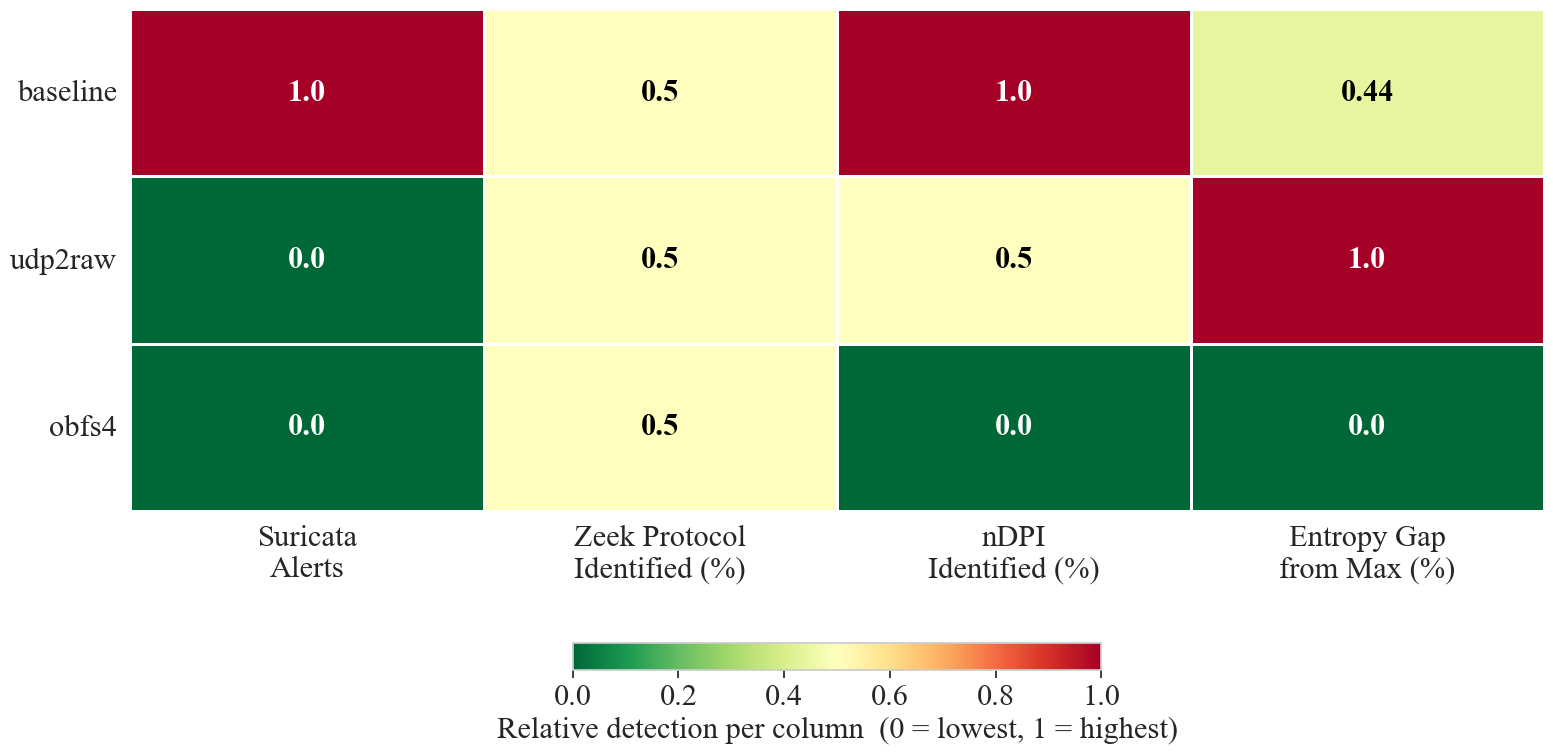

In [13]:
if not df_runs.empty:
    valid_runs = df_runs[df_runs['packets_df'].apply(lambda x: x is not None and not x.empty)]
    
    summary_rows = []
    
    for _, row in valid_runs.iterrows():
        pdf = row['packets_df']
        sizes = pdf['frame.len'].dropna()
        iat = calculate_iat(pdf)
        
        # Suricata alerts
        alerts_df = row['alerts']
        alert_count = len(alerts_df) if not alerts_df.empty else 0
        alert_sigs = ", ".join(alerts_df['signature'].unique()) if not alerts_df.empty else "None"
        
        # Zeek service detection
        zdf = row['zeek_df']
        if zdf is not None and not zdf.empty and 'service' in zdf.columns:
            services = zdf['service'].replace('-', 'unknown').fillna('unknown')
            top_service = services.value_counts().index[0]
        else:
            top_service = "N/A"
        
        # nDPI protocol
        ndpi_proto = "N/A"
        summary_path = os.path.join(row['path'], "ndpi", "summary.txt")
        if os.path.exists(summary_path):
            import re
            with open(summary_path) as f:
                match = re.search(r'Detected protocols:\n\t(\S+)', f.read())
                if match:
                    ndpi_proto = match.group(1)
        
        # TLS Client Hello check
        tls_hello_count = 0
        total_443 = 0
        if 'tls.handshake.type' in pdf.columns and 'tcp.dstport' in pdf.columns:
            pdf_tmp = pdf.copy()
            pdf_tmp['tcp.dstport'] = pd.to_numeric(pdf_tmp['tcp.dstport'], errors='coerce')
            https_pkts = pdf_tmp[pdf_tmp['tcp.dstport'] == 443]
            total_443 = len(https_pkts)
            if total_443 > 0:
                tls_hello_count = len(https_pkts[https_pkts['tls.handshake.type'] == 1])
        
        # Entropy
        mean_entropy = "N/A"
        if 'df_entropy' in dir() and not df_entropy.empty:
            ent_subset = df_entropy[df_entropy['label'] == row['label']]
            if not ent_subset.empty:
                mean_entropy = f"{ent_subset['entropy'].mean():.3f}"
        
        # Throughput
        # For streaming runs aggregate all runs of this scenario; for burst show N/A
        if row['mode'] == 'streaming':
            scen_stream = df_runs[(df_runs['scenario'] == row['scenario']) &
                                  (df_runs['mode'] == 'streaming') &
                                  (df_runs['throughput_mbps'] > 0)]['throughput_mbps']
            if len(scen_stream) > 1:
                throughput = f"{scen_stream.mean():.1f} ± {scen_stream.std():.1f} (n={len(scen_stream)})"
            elif len(scen_stream) == 1:
                throughput = f"{scen_stream.iloc[0]:.1f} (n=1)"
            else:
                throughput = "N/A"
        else:
            throughput = "N/A (burst)"
        
        summary_rows.append({
            'Scenario': row['label'],
            'Suricata Alerts': alert_count,
            'nDPI Protocol': ndpi_proto,
            'Zeek Service-ID': top_service,
            'Mean Pkt Size (B)': f"{sizes.mean():.1f}",
            'Median Pkt Size (B)': f"{sizes.median():.1f}",
            'Pkt Size Std Dev': f"{sizes.std():.1f}",
            'Mean IAT (ms)': f"{iat.mean():.4f}" if len(iat) > 0 else "N/A",
            'TLS Hello / Port 443': f"{tls_hello_count}/{total_443}" if total_443 > 0 else "N/A",
            'Mean Entropy (bits)': mean_entropy,
            'Throughput (Mbps)': throughput,
            'Retransmits': row.get('retransmits', 'N/A')
        })
    
    df_summary = pd.DataFrame(summary_rows)
    
    # Display full summary
    print("=" * 100)
    print("COMPREHENSIVE SUMMARY TABLE — Scenario x Metric")
    print("=" * 100)
    display(df_summary.style.set_caption(
        "Summary: All metrics across all scenarios and traffic modes"
    ).set_properties(**{'text-align': 'center'}))
    
    # ── Condensed comparison table (burst mode only) ─────────────────
    print("\n")
    print("=" * 100)
    print("CONDENSED COMPARISON (Burst Mode Only)")
    print("=" * 100)
    
    burst_summary = df_summary[df_summary['Scenario'].str.contains('burst')]
    if not burst_summary.empty:
        burst_t = burst_summary.set_index('Scenario').T
        display(burst_t.style.set_caption(
            "Burst Mode: Side-by-Side Scenario Comparison"
        ))
    
    # ── Detection Effectiveness Heatmap (per-column normalisation) ───
    print("\n")
    
    burst_runs = valid_runs[valid_runs['mode'] == 'burst']
    detect_data = []
    for _, row in burst_runs.iterrows():
        alerts_df = row['alerts']
        alert_count = len(alerts_df) if not alerts_df.empty else 0
        
        # nDPI detection score (0-100)
        ndpi_proto = "N/A"
        summary_path = os.path.join(row['path'], "ndpi", "summary.txt")
        if os.path.exists(summary_path):
            import re
            with open(summary_path) as f:
                match = re.search(r'Detected protocols:\n\t(\S+)', f.read())
                if match:
                    ndpi_proto = match.group(1)
        
        ndpi_score = 100 if ndpi_proto == 'WireGuard' else (50 if ndpi_proto not in ('Unknown', 'N/A') else 0)
        
        # Zeek identification
        zdf = row['zeek_df']
        zeek_identified = 0
        if zdf is not None and not zdf.empty and 'service' in zdf.columns:
            services = zdf['service'].replace('-', 'unknown').fillna('unknown')
            zeek_identified = (services != 'unknown').sum() / max(len(services), 1) * 100
        
        # Entropy deviation from max
        ent_dev = 0
        if 'df_entropy' in dir() and not df_entropy.empty:
            ent_sub = df_entropy[(df_entropy['label'] == row['label'])]
            if not ent_sub.empty:
                ent_dev = (8.0 - ent_sub['entropy'].mean()) / 8.0 * 100
        
        detect_data.append({
            'Scenario': row['scenario'],
            'Suricata\nAlerts': alert_count,
            'nDPI\nIdentified (%)': ndpi_score,
            'Zeek Protocol\nIdentified (%)': zeek_identified,
            'Entropy Gap\nfrom Max (%)': ent_dev
        })
    
    if detect_data:
        df_detect = pd.DataFrame(detect_data).set_index('Scenario')

        # Reorder columns: Suricata → Zeek → nDPI → Entropy
        col_order = ['Suricata\nAlerts', 'Zeek Protocol\nIdentified (%)',
                     'nDPI\nIdentified (%)', 'Entropy Gap\nfrom Max (%)']
        df_detect = df_detect[[c for c in col_order if c in df_detect.columns]]

        # Normalise each column independently to [0, 1] — both colour AND annotation
        df_norm = df_detect.copy()
        for col in df_norm.columns:
            col_min = df_norm[col].min()
            col_max = df_norm[col].max()
            if col_max > col_min:
                df_norm[col] = (df_norm[col] - col_min) / (col_max - col_min)
            else:
                df_norm[col] = 0.5

        from matplotlib.cm import ScalarMappable
        from matplotlib.colors import Normalize

        fig, ax = plt.subplots(figsize=(16, 8))
        sns.heatmap(df_norm, annot=df_norm.round(2).values, fmt='', cmap='RdYlGn_r',
                    linewidths=1, ax=ax, cbar=False, vmin=0, vmax=1,
                    annot_kws={'size': 22, 'weight': 'bold'})

        # Dynamic text color: black on light (yellow) cells, white on dark cells
        flat_vals = df_norm.values.flatten()
        for text, val in zip(ax.texts, flat_vals):
            text.set_color('black' if 0.25 < val < 0.75 else 'white')

        ax.tick_params(axis='y', labelsize=22, rotation=0)
        ax.tick_params(axis='x', labelsize=22)
        ax.set_ylabel('')

        # Horizontal colorbar at bottom center
        sm = ScalarMappable(cmap='RdYlGn_r', norm=Normalize(vmin=0, vmax=1))
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, orientation='horizontal',
                            fraction=0.04, pad=0.2)
        cbar.set_label('Relative detection per column  (0 = lowest, 1 = highest)',
                       fontsize=22)
        cbar.ax.tick_params(labelsize=22)

        plt.tight_layout()
        plt.show()